# Statistical Analysis of Apple Stock Returns and Volatility

## 1. Project Goal

In this project, we analyze Apple stock data in order to gain insights into the stock's price behavior, fluctuations, and return distribution. 

Moreover, we investigate possible trends and patterns in the stock returns, as well as how the stock's volatility evolves over time.

## 2. Importing Libraries

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

## 3. Data Collection

We use historical Apple stock data obtained from Yahoo Finance through the yfinance library.

In [57]:
apple = yf.download('AAPL', start='2020-01-01', end='2025-01-01', auto_adjust = False)
apple.columns = apple.columns.droplevel(1)

apple.head()

[*********************100%***********************]  1 of 1 completed


Price,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2020-01-02,72.333855,75.087502,75.150002,73.797501,74.059998,135480400
2020-01-03,71.630653,74.357498,75.144997,74.125000,74.287498,146322800
2020-01-06,72.201401,74.949997,74.989998,73.187500,73.447502,118387200
2020-01-07,71.861847,74.597504,75.224998,74.370003,74.959999,108872000
2020-01-08,73.017838,75.797501,76.110001,74.290001,74.290001,132079200


The dataset contains data about opening and closing prices, daily highs and lows, adjusted closing prices, and trading volume.

## 4. Data Inspection & Cleaning

Before proceeding with the analysis, we inspect the structure and quality of the dataset.

In [58]:
apple.shape

(1258, 6)

In [59]:
apple.columns

Index(['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='str', name='Price')

In [60]:
apple.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1258 entries, 2020-01-02 to 2024-12-31
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Adj Close  1258 non-null   float64
 1   Close      1258 non-null   float64
 2   High       1258 non-null   float64
 3   Low        1258 non-null   float64
 4   Open       1258 non-null   float64
 5   Volume     1258 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 68.8 KB


In [61]:
apple.isnull().sum()

Price
Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64

All columns are numerical and no missing values appear to be present in the dataset.

In [62]:
apple.describe()

Price,Adj Close,Close,High,Low,Open,Volume
count,1258.000000,1258.000000,1258.000000,1258.000000,1258.000000,1.258000e+03
mean,151.377786,154.108800,155.660348,152.379123,153.951948,9.057103e+07
std,41.851999,41.520877,41.654310,41.305929,41.466618,5.324438e+07
min,54.163689,56.092499,57.125000,53.152500,57.020000,2.323470e+07
25%,126.279114,129.624996,130.755005,127.505001,129.017506,5.546825e+07
50%,149.968597,152.805000,154.570000,150.825005,152.575005,7.628335e+07
75%,175.902016,178.850006,180.160000,177.115005,178.500004,1.077425e+08
max,257.375610,259.019989,260.100006,257.630005,258.190002,4.265100e+08


The descriptive statistics provide an initial overview of the stock price levels, variability, and trading activity during the examined period.

## 5. Exploratory Price Analysis

We begin our analysis by examining the evolution of Apple's stock price over time.

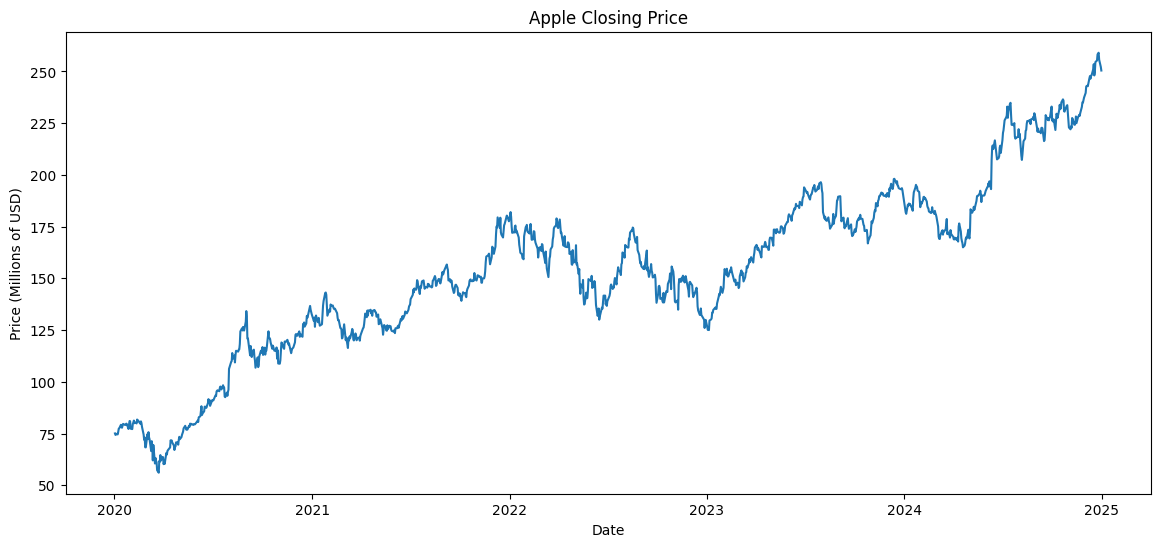

In [63]:
plt.figure(figsize=(14, 6))
plt.plot(apple['Close'])
plt.title('Apple Closing Price')
plt.xlabel('Date')
plt.ylabel('Price (Millions of USD)')
plt.show()

The stock price exhibits a clear long-term upward trend, accompanied by periods of increased volatility and sharp market movements.

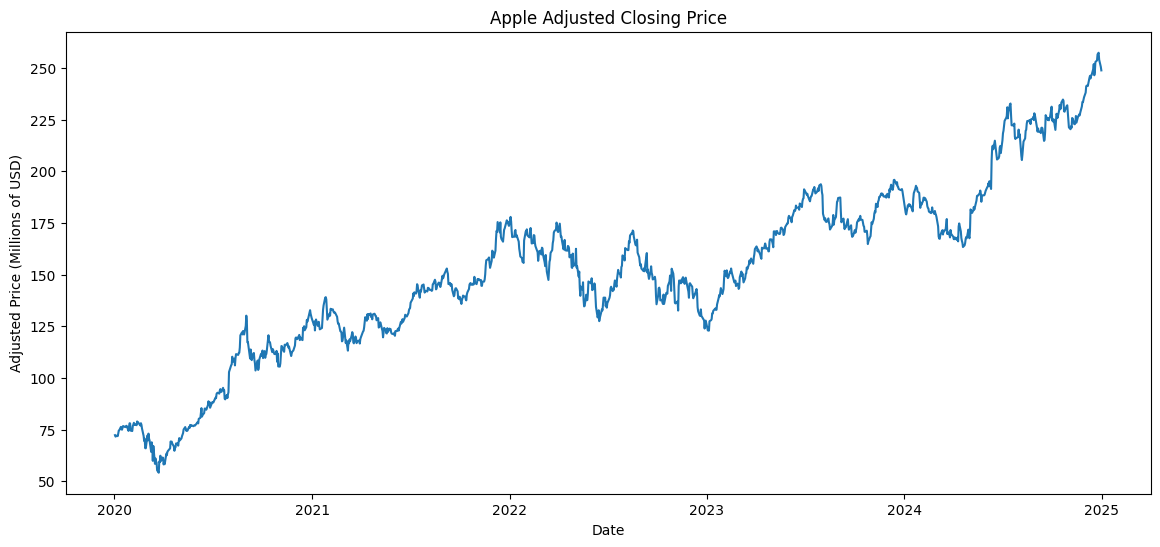

In [64]:
plt.figure(figsize=(14, 6))
plt.plot(apple['Adj Close'])
plt.title('Apple Adjusted Closing Price')
plt.xlabel('Date')
plt.ylabel('Adjusted Price (Millions of USD)')
plt.show()

The adjusted closing price reflects corporate actions such as stock splits and dividends, providing a more accurate representation of the stock's historical value. Throuought this project we work with adjasted closing price.

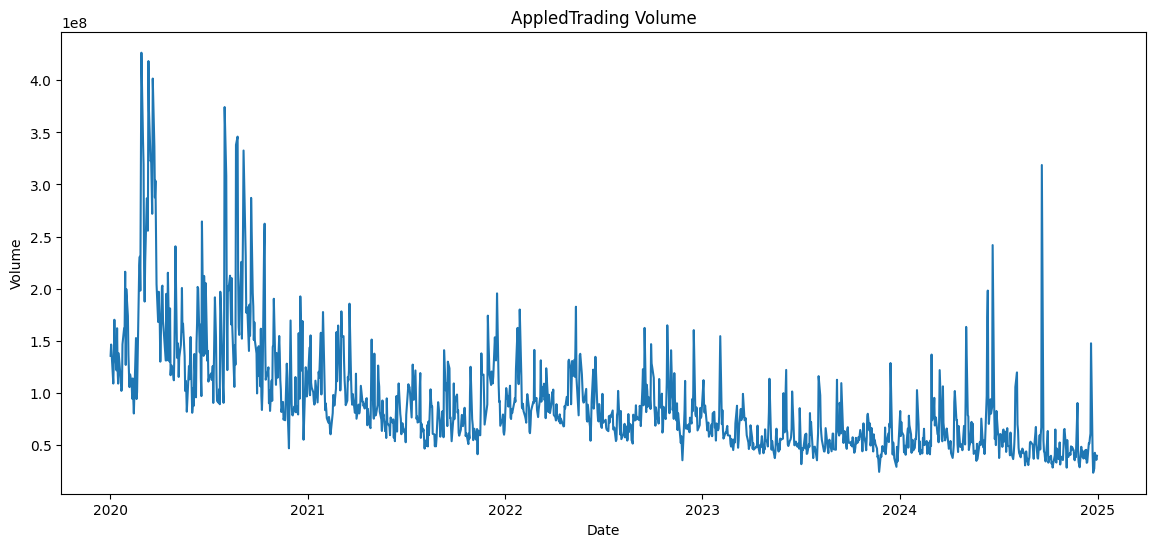

In [65]:
plt.figure(figsize=(14, 6))

plt.plot(apple['Volume'])

plt.title('AppledTrading Volume')
plt.xlabel('Date')
plt.ylabel('Volume')

plt.show()

Trading volume fluctuates considerably over time, with significant spikes during periods of heightened market activity.

## 6. Moving Averages Analysis

Moving averages are commonly used in financial analysis to smooth short-term fluctuations and identify underlying trends in stock prices.

In [66]:
apple['MA30'] = apple['Adj Close'].rolling(window=30).mean()
apple['MA100'] = apple['Adj Close'].rolling(window=100).mean()

The 30-day moving average captures shorter-term market movements, while the 100-day moving average reflects longer-term trends.

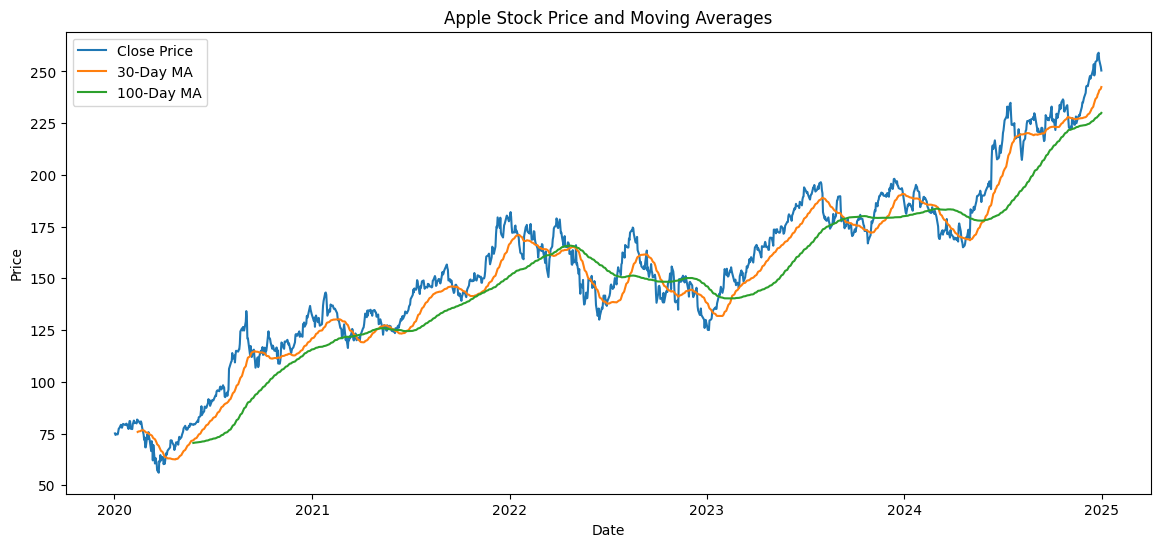

In [67]:
plt.figure(figsize=(14,6))

plt.plot(apple['Close'], label='Close Price')
plt.plot(apple['MA30'], label='30-Day MA')
plt.plot(apple['MA100'], label='100-Day MA')

plt.title('Apple Stock Price and Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()

plt.show()

Intersections between the short-term and long-term moving averages may indicate potential changes in market momentum.

In particular, when the 30-day moving average crosses above the 100-day moving average, it may suggest a strengthening upward trend, while the opposite case may indicate weakening momentum.

## 7. Log Returns Analysis

In financial analysis, returns are often more informative than raw stock prices, since they measure the relative change in value over time.

In this section, we calculate and analyze Apple's daily logarithmic returns.

The simple daily return of a stock is defined as the percentage change in price from one trading day to the next and it is given by the following formula:
$$r_t = \frac{P_t - P_{t-1}}{P_{t-1}},$$

where $P_t$ is the stock price at time $t$.

Although simple returns are intuitive and widely used, logarithmic returns are often preferred in quantitative finance because of their useful mathematical properties. Log-returns are given by the following formula:
$$R_t = \log(\frac{P_t}{P_{t-1}})$$

Logarithmic returns are additive over time and are closely connected to continuously compounded returns.

Moreover, they are often more convenient for statistical modeling and stochastic financial models such as Geometric Brownian Motion.


In financial analysis, returns are often more informative than raw stock prices, since they measure the relative change in value over time.

There are two common types of returns: simple returns and logarithmic returns, given by the following formulas respectively:

$$
r_t = \frac{P_t - P_{t-1}}{P_{t-1}}
$$

$$
R_t = \log\left(\frac{P_t}{P_{t-1}}\right)
$$

It is clear that simple returns express the percentage change in price from one trading day to the next, while logarithmic returns measure the same change on a logarithmic scale.

In this section, we use logarithmic returns because they are additive over time, which makes them more convenient for mathematical calculations and statistical modeling.

Moreover, logarithmic returns are widely used in stochastic financial models such as Geometric Brownian Motion.

In [68]:
apple['Log Returns'] = np.log(apple['Adj Close'] / apple['Adj Close'].shift(1))

apple[['Adj Close', 'Log Returns']].head()

Price,Adj Close,Log Returns
Date,,
2020-01-02,72.333855,NaN
2020-01-03,71.630653,-0.009769
2020-01-06,72.201401,0.007936
2020-01-07,71.861847,-0.004714
2020-01-08,73.017838,0.015958


We now visualize the log returns in order to examine their variability and identify periods of unusually large market movements.

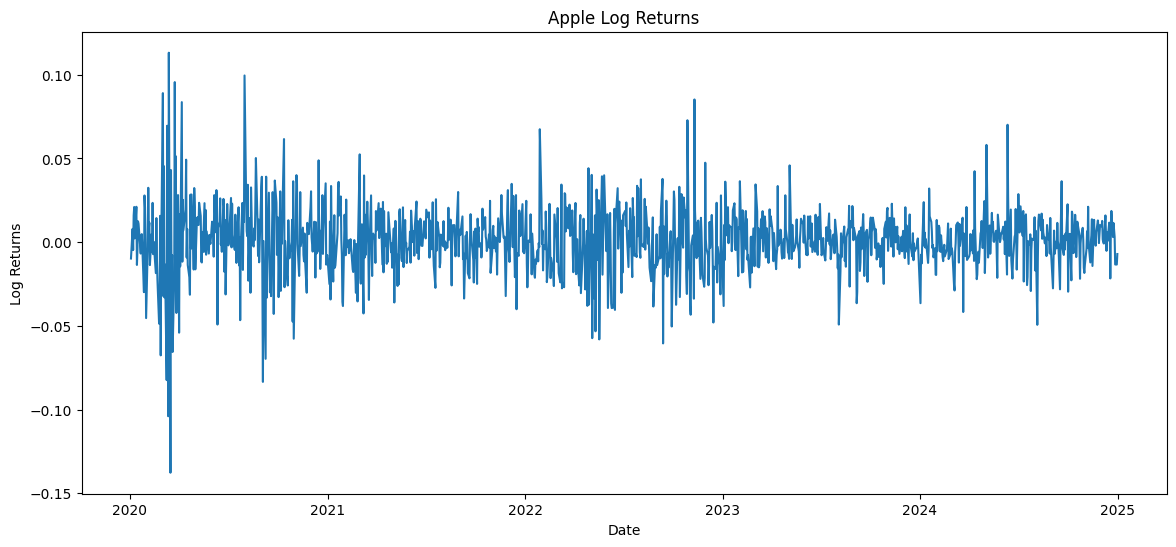

In [69]:
plt.figure(figsize=(14,6))

plt.plot(apple['Log Returns'])

plt.title('Apple Log Returns')
plt.xlabel('Date')
plt.ylabel('Log Returns')

plt.show()

The log returns fluctuate around zero and exhibit periods of increased volatility, characterized by larger positive and negative movements.

We next examine some descriptive statistics of the log returns.

In [70]:
apple['Log Returns'].describe()

count    1257.000000
mean        0.000983
std         0.019940
min        -0.137708
25%        -0.008461
50%         0.001186
75%         0.011918
max         0.113157
Name: Log Returns, dtype: float64

The descriptive statistics provide insight into the average daily performance of the stock, as well as the magnitude of its fluctuations and extreme market movements.